Installing dependencies.

In [ ]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Device: cuda


Configuration

In [ ]:
DATA_DIR    = "/content/drive/MyDrive/HateSpeech_dataset"  # folder containing uploaded files
PROJECT_DIR = "output"                                     # where processed files & model are saved
MODEL_NAME  = "cardiffnlp/twitter-roberta-base-hate"

BATCH_SIZE  = 16
MAX_LEN     = 128
EPOCHS      = 7
LR          = 2e-5
WARMUP_FRAC = 0.1                                          # fraction of steps used for warm-up


os.makedirs(PROJECT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Load and parse dataset

In [ ]:
def load_dataset(path: str) -> pd.DataFrame:
    """
    Parse dataset.json into a flat DataFrame.

    Each post gets the majority-vote label from its annotators.
    Ties are broken by whichever label appears first in the list.
    """
    with open(path, "r") as f:
        raw = json.load(f)

    records = []
    for pid, item in raw.items():
        text   = " ".join(item["post_tokens"])
        labels = [ann["label"] for ann in item["annotators"]]
        label  = max(set(labels), key=labels.count)
        records.append({"post_id": str(pid), "text": text, "label": label})

    return pd.DataFrame(records)


df = load_dataset(os.path.join(DATA_DIR, "dataset.json"))
print(f"Total samples: {len(df)}")
print(df.head())

Total samples: 20148
                       post_id  \
0  1179055004553900032_twitter   
1  1179063826874032128_twitter   
2  1178793830532956161_twitter   
3  1179088797964763136_twitter   
4  1179085312976445440_twitter   

                                                text       label  
0  i dont think im getting my baby them white 9 h...      normal  
1  we cannot continue calling ourselves feminists...      normal  
2                      nawt yall niggers ignoring me      normal  
3  <user> i am bit confused coz chinese ppl can n...  hatespeech  
4  this bitch in whataburger eating a burger with...  hatespeech  


Train / Validation / Test split

In [ ]:
def split_dataframe(df: pd.DataFrame, splits_path: str):
    """Return (train_df, val_df, test_df) using the official post-ID splits."""
    with open(splits_path, "r") as f:
        splits = json.load(f)

    train_ids = set(map(str, splits["train"]))
    val_ids   = set(map(str, splits["val"]))
    test_ids  = set(map(str, splits["test"]))

    train_df = df[df["post_id"].isin(train_ids)].copy()
    val_df   = df[df["post_id"].isin(val_ids)].copy()
    test_df  = df[df["post_id"].isin(test_ids)].copy()

    return train_df, val_df, test_df


train_df, val_df, test_df = split_dataframe(df, os.path.join(DATA_DIR, "post_id_divisions.json"))
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Train: 15383  Val: 1922  Test: 1924


Label encoding

In [ ]:
classes  = np.load(os.path.join(DATA_DIR, "classes.npy"), allow_pickle=True)
label2id = {c: i for i, c in enumerate(classes)}
id2label = {i: c for i, c in enumerate(classes)}

for split in (train_df, val_df, test_df):
    split["label_id"] = split["label"].map(label2id)

print("Label distribution (train):")
print(train_df["label"].value_counts())

# Optionally persist processed splits
train_df.to_csv(os.path.join(PROJECT_DIR, "train_processed.csv"), index=False)
val_df.to_csv(os.path.join(PROJECT_DIR, "val_processed.csv"),   index=False)
test_df.to_csv(os.path.join(PROJECT_DIR, "test_processed.csv"),  index=False)
np.save(os.path.join(PROJECT_DIR, "classes.npy"), classes)
print("Processed splits saved.")

Label distribution (train):
label
normal        6251
hatespeech    4748
offensive     4384
Name: count, dtype: int64
Processed splits saved.


Dataset and Dataloaders

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class HateSpeechDataset(Dataset):
    """Tokenises texts on the fly; returns tensors ready for the model."""

    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = MAX_LEN):
        self.texts    = df["text"].tolist()
        self.labels   = df["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_loader = DataLoader(
    HateSpeechDataset(train_df, tokenizer), batch_size=BATCH_SIZE, shuffle=True
)
val_loader  = DataLoader(HateSpeechDataset(val_df,   tokenizer), batch_size=BATCH_SIZE)
test_loader = DataLoader(HateSpeechDataset(test_df,  tokenizer), batch_size=BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Model and optimiser

In [ ]:
num_labels = len(classes)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    ignore_mismatched_sizes=True,
)
model.to(device)

# Class-weighted loss to handle label imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"].values,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
print("Class weights:", class_weights)

total_steps = len(train_loader) * EPOCHS
optimizer   = AdamW(model.parameters(), lr=LR)
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_FRAC * total_steps),
    num_training_steps=total_steps,
)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([3])          
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([2, 768]) vs model:torch.Size([3, 768])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Class weights: [1.07996349 0.82029542 1.169632  ]


Training loop

In [ ]:
def evaluate(model, loader) -> tuple[list, list]:
    """Return (predictions, true_labels) for a DataLoader."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
            )
            preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            trues.extend(batch["labels"].numpy())
    return preds, trues


for epoch in range(1, EPOCHS + 1):
    # — Training —
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
        )
        loss = criterion(outputs.logits, batch["labels"].to(device))
        loss.backward()

        optimizer.step()
        scheduler.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # — Validation —
    val_preds, val_trues = evaluate(model, val_loader)
    val_f1 = f1_score(val_trues, val_preds, average="macro")

    print(f"Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Macro-F1: {val_f1:.4f}")

Epoch 1/7: 100%|██████████| 962/962 [05:50<00:00,  2.74it/s]


Epoch 1/7 | Loss: 0.8374 | Val Macro-F1: 0.6647


Epoch 2/7: 100%|██████████| 962/962 [05:58<00:00,  2.68it/s]


Epoch 2/7 | Loss: 0.6528 | Val Macro-F1: 0.6946


Epoch 3/7: 100%|██████████| 962/962 [05:58<00:00,  2.68it/s]


...

Epoch 5/7 | Loss: 0.2337 | Val Macro-F1: 0.7001


Epoch 6/7: 100%|██████████| 962/962 [05:58<00:00,  2.68it/s]


Epoch 6/7 | Loss: 0.1557 | Val Macro-F1: 0.6897


Epoch 7/7: 100%|██████████| 962/962 [05:58<00:00,  2.68it/s]


Epoch 7/7 | Loss: 0.1026 | Val Macro-F1: 0.6913


Save model and tokenizer

In [ ]:
model_dir = os.path.join(PROJECT_DIR, "roberta_3class_final")
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)
print(f"Model and tokenizer saved to: {model_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: output/roberta_3class_final


Evaluation on test set

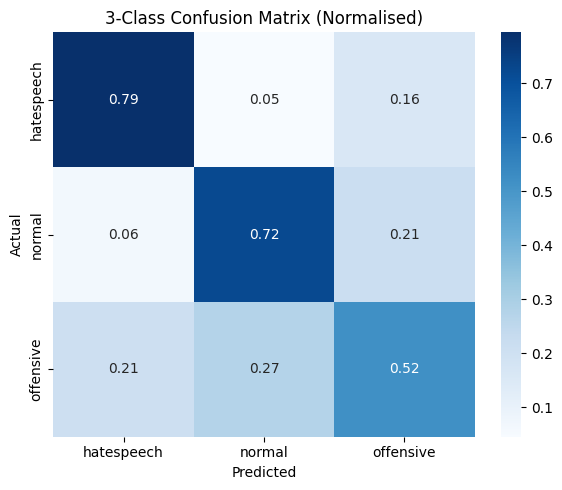


Classification Report:
              precision    recall  f1-score   support

  hatespeech       0.74      0.79      0.77       594
      normal       0.76      0.72      0.74       782
   offensive       0.52      0.52      0.52       548

    accuracy                           0.69      1924
   macro avg       0.67      0.68      0.68      1924
weighted avg       0.69      0.69      0.69      1924



In [ ]:
test_preds, test_trues = evaluate(model, test_loader)

# Confusion matrix
cm            = confusion_matrix(test_trues, test_preds)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("3-Class Confusion Matrix (Normalised)")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(test_trues, test_preds, target_names=classes))

Inference on sample texts

In [ ]:
def predict(text: str) -> tuple[str, float]:
    """Return (predicted_class, confidence) for a single text."""
    model.eval()
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
    )
    with torch.no_grad():
        logits = model(
            enc["input_ids"].to(device),
            attention_mask=enc["attention_mask"].to(device),
        ).logits
    probs      = torch.softmax(logits, dim=1).squeeze()
    pred_idx   = torch.argmax(probs).item()
    return classes[pred_idx], probs[pred_idx].item()


sample_texts = [
    "I love everyone in my community!",
    "I hate people from that group.",
    "You are so stupid!",
]

print("\nSample Inference:")
for text in sample_texts:
    label, confidence = predict(text)
    print(f"  Text      : {text}")
    print(f"  Predicted : {label}  (confidence: {confidence:.2%})\n")


Sample Inference:
  Text      : I love everyone in my community!
  Predicted : normal  (confidence: 99.90%)

  Text      : I hate people from that group.
  Predicted : hatespeech  (confidence: 94.43%)

  Text      : You are so stupid!
  Predicted : offensive  (confidence: 99.10%)

